## With existing .json from arrivaltimeCorrection building mixture populatuon to sample from and test with artifical IFCB sampling

end goal is to see how mixtures of different underlying particle distributions affect sample concentration estimates


In [55]:
import pandas as pd
import numpy as np

Alex_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/AlexHighV_corrected_arrivals.json")
Jata_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/jataHighV_corrected_arrivals.json")

In [56]:
print(f"Number of times in Alex: {len(Alex_corrected)}")
print(f"Number of times in Jata: {len(Jata_corrected)}")

Number of times in Alex: 1324124
Number of times in Jata: 2147432


In [57]:
jata_arrivals = Jata_corrected["arrival_times"].values
alex_arrivals = Alex_corrected["arrival_times"].values

print(f"Number of unique arrival times in Alex: {len(np.unique(alex_arrivals))}")
print(f"Number of total arrival times in Alex: {len(alex_arrivals)}")
print(f"Number of unique arrival times in Jata: {len(np.unique(jata_arrivals))}")
print(f"Number of total arrival times in Jata: {len(jata_arrivals)}")

Number of unique arrival times in Alex: 1324124
Number of total arrival times in Alex: 1324124
Number of unique arrival times in Jata: 2147432
Number of total arrival times in Jata: 2147432


In [13]:
Alex_corrected.describe()

,seed,n_observed,n_corrected,arrival_times,source_index
count,1323258.0,1323258.0,1323258.0,1.323258e+06,1.323258e+06
mean,42.0,443832.0,1323258.0,4.658360e+02,2.213318e+05
std,0.0,0.0,0.0,3.185150e+02,1.279229e+05
min,42.0,443832.0,1323258.0,7.535460e-01,0.000000e+00
25%,42.0,443832.0,1323258.0,1.956707e+02,1.103370e+05
50%,42.0,443832.0,1323258.0,3.952393e+02,2.209150e+05
75%,42.0,443832.0,1323258.0,6.998926e+02,3.315520e+05
max,42.0,443832.0,1323258.0,1.202095e+03,4.438310e+05


In [ ]:
# import numpy as np
# import pandas as pd

# def make_mixture(
#     pools,
#     total_particles,
#     fractions,
#     scenario_id,
#     seed=None,
# ):
#     """
#     pools: dict like {"A": df_A, "B": df_B}
#     fractions: dict like {"A": 0.7, "B": 0.3}
#     """
#     rng = np.random.default_rng(seed)
#     rows = []

#     # turn fractions into integer counts
#     types = list(fractions.keys())
#     counts = {}
#     remaining = total_particles

#     for t in types[:-1]:
#         n = int(round(total_particles * fractions[t]))
#         counts[t] = n
#         remaining -= n

#     counts[types[-1]] = remaining

#     for t in types:
#         pool = pools[t]
#         n = counts[t]

#         sampled = pool.sample(
#             n=n,
#             replace=True,
#             random_state=rng.integers(0, 1_000_000_000)
#         ).copy()

#         sampled["scenario_id"] = scenario_id
#         sampled["particle_type"] = t
#         sampled["particle_id"] = np.arange(len(sampled))

#         rows.append(sampled[["scenario_id", "particle_id", "particle_type", "arrival_time"]])

#     out = pd.concat(rows, ignore_index=True)
#     return out.sort_values("arrival_time").reset_index(drop=True)

In [ ]:
# from itertools import product

# total_loads = [100, 250, 500, 1000]
# fractions_A = [0.2, 0.5, 0.8]

# scenario_frames = []
# scenario_meta = []

# scenario_id = 0

# for total_particles, frac_A in product(total_loads, fractions_A):
#     scenario_id += 1

#     fractions = {
#         "A": frac_A,
#         "B": 1 - frac_A,
#     }

#     mix_df = make_mixture(
#         pools={"A": type_a_pool, "B": type_b_pool},
#         total_particles=total_particles,
#         fractions=fractions,
#         scenario_id=scenario_id,
#         seed=42 + scenario_id,
#     )

#     scenario_frames.append(mix_df)
#     scenario_meta.append({
#         "scenario_id": scenario_id,
#         "total_particles": total_particles,
#         "frac_A": frac_A,
#         "frac_B": 1 - frac_A,
#     })

# all_events = pd.concat(scenario_frames, ignore_index=True)
# scenario_table = pd.DataFrame(scenario_meta)

## Above is overly complex chat nonsense below is much simpler way to approach this problem


In [62]:
import numpy as np
import pandas as pd

def make_mixture(
    Arrivals_A,
    Type_A,
    Arrivals_B,
    Type_B,
    total_particles,
    fraction_A,
    scenario_id,
    seed=None,
):
    """
    Arrivals_A: pd.Series of arrival times for type A particles
    Type_A: str, label for type A particles
    Arrivals_B: pd.Series of arrival times for type B particles
    Type_B: str, label for type B particles
    total_particles: int, total number of particles to sample
    fraction_A: float, fraction of type A particles in the mixture
    scenario_id: str, identifier for the scenario
    seed: int, random seed for reproducibility
    """
    rng = np.random.default_rng(seed)

    # Calculate the number of particles of each type
    n_A = int(round(total_particles * fraction_A))
    n_B = total_particles - n_A


    n_A_sampled = rng.poisson(n_A)
    n_B_sampled = rng.poisson(n_B)

    # Sample arrival times for each type
    sampled_A = rng.choice(np.asarray(Arrivals_A), n_A_sampled, replace=False)
    sampled_B = rng.choice(np.asarray(Arrivals_B), n_B_sampled, replace=False)

    # Create DataFrames for each type
    df_A = pd.DataFrame({
        "scenario_id": scenario_id,
        "Source_group": Type_A,
        "arrival_time": sampled_A,
        "total_particles": total_particles,
        "fraction_A": fraction_A
    })

    df_B = pd.DataFrame({
        "scenario_id": scenario_id,
        "Source_group": Type_B,
        "arrival_time": sampled_B,
        "total_particles": total_particles,
        "fraction_A": fraction_A
    })

    # Concatenate the DataFrames and sort by arrival time
    mixture_df = pd.concat([df_A, df_B], ignore_index=True)
    mixture_df = mixture_df.sort_values("arrival_time").reset_index(drop=True)

    return mixture_df

In [110]:
## Good for understanding fractions and building out

scenario_id = ["20A:80J", "40A:60J", "60A:40J", "80A:20J"]
fractions_A = [0.2, 0.4, 0.6, 0.8]
total_particles = [15000, 20000, 25000, 30000]

summary_df = pd.DataFrame()

for i in range(len(scenario_id)):
    for total in total_particles:
        df = make_mixture(
            Arrivals_A=Alex_corrected["arrival_times"],
            Type_A="Alexandrium",
            Arrivals_B=Jata_corrected["arrival_times"],
            Type_B="Jata",
            total_particles=total,
            fraction_A=fractions_A[i],
            scenario_id=f"{scenario_id[i]}_{total}",
            seed=42 + i + total
        )

        summary_df = pd.concat([summary_df, df], ignore_index=True)

In [59]:
## use this to fill in heat map if you want to see all combinations of a set of target concentrations

def make_mixture_from_concentrations(
    Arrivals_A,
    Type_A,
    Arrivals_B,
    Type_B,
    alex_conc,
    jata_conc,
    scenario_id,
    seed=None,
):
    total_particles = alex_conc + jata_conc
    fraction_A = alex_conc / total_particles

    return make_mixture(
        Arrivals_A=Arrivals_A,
        Type_A=Type_A,
        Arrivals_B=Arrivals_B,
        Type_B=Type_B,
        total_particles=int(total_particles),
        fraction_A=fraction_A,
        scenario_id=scenario_id,
        seed=seed,
    )

In [104]:
alex_vals = [ 5000, 10000, 15000, 20000, 25000, 30000, 35000]
jata_vals = [ 5000, 10000, 15000, 20000, 25000, 30000, 35000]

summary_df = pd.DataFrame()

for alex in alex_vals:
    for jata in jata_vals:
        df = make_mixture_from_concentrations(
            Arrivals_A=Alex_corrected["arrival_times"],
            Type_A="Alexandrium",
            Arrivals_B=Jata_corrected["arrival_times"],
            Type_B="Jata",
            alex_conc=alex,
            jata_conc=jata,
            scenario_id=f"Alex{alex}_Jata{jata}",
            seed=42+alex+jata,
        )

        summary_df = pd.concat([summary_df, df], ignore_index=True)

In [64]:
summary_df.head()



,scenario_id,Source_group,arrival_time,total_particles,fraction_A
0,Alex25000_Jata25000,Jata,3.205586,50000,0.5
1,Alex25000_Jata25000,Jata,3.370233,50000,0.5
2,Alex25000_Jata25000,Jata,5.690864,50000,0.5
3,Alex25000_Jata25000,Alexandrium,7.157386,50000,0.5
4,Alex25000_Jata25000,Alexandrium,7.243973,50000,0.5


In [105]:
print(f"Number of unique arrival times : {len(np.unique(summary_df["arrival_time"]))}")
print(f"Number of total arrival times : {len(summary_df["arrival_time"])}")


Number of unique arrival times : 1380856
Number of total arrival times : 1961244


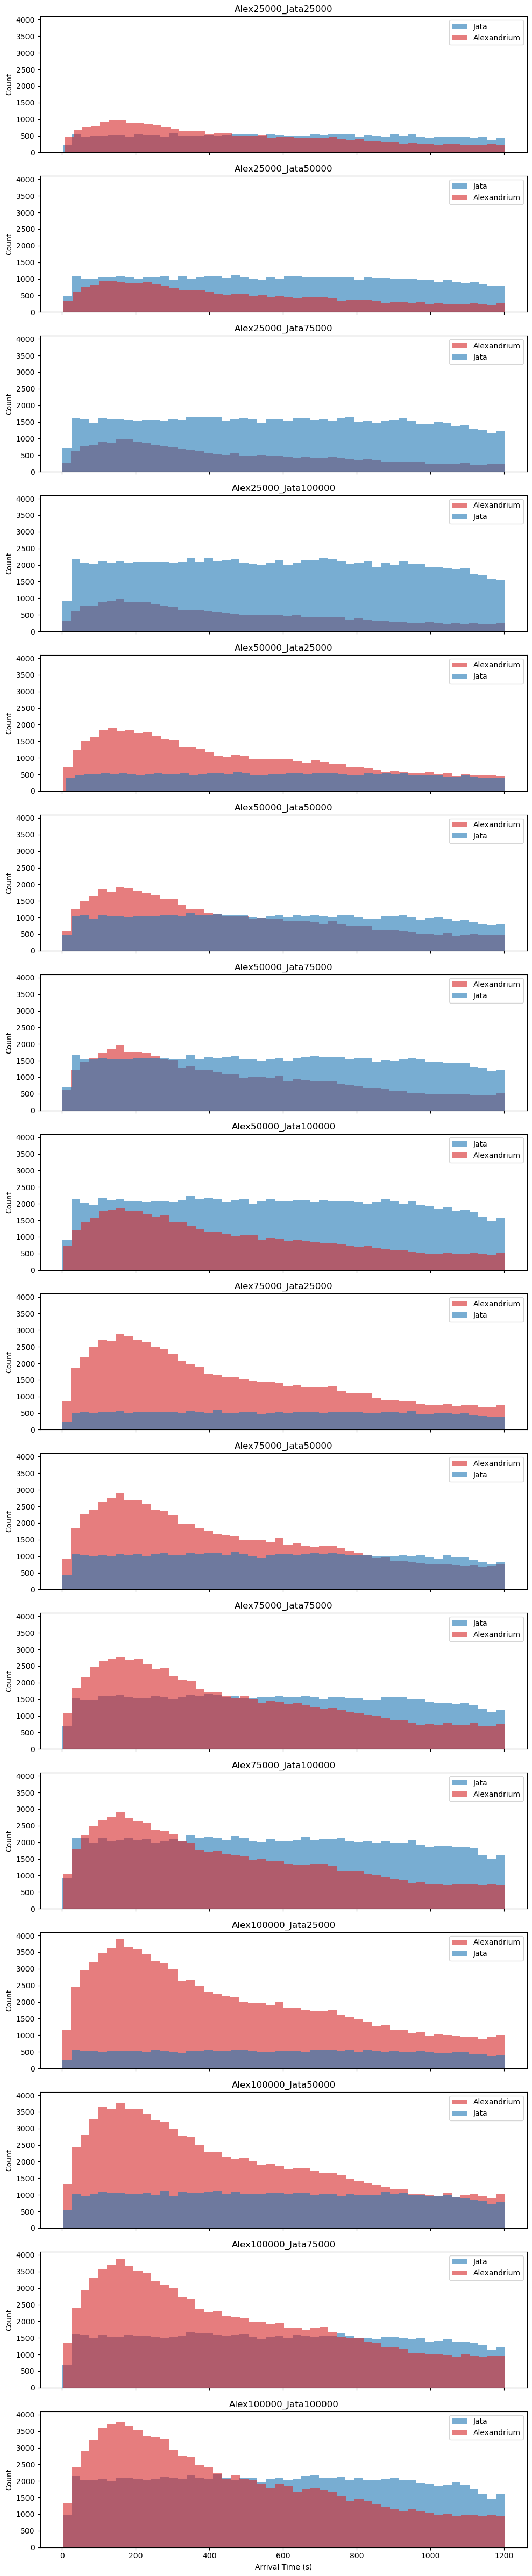

In [23]:
import matplotlib.pyplot as plt

scenarios = summary_df["scenario_id"].unique()

fig, axes = plt.subplots(
    len(scenarios), 1,
    figsize=(10, 3 * len(scenarios)),
    sharex=True,
    sharey=True
)

# If only one scenario, make axes iterable
if len(scenarios) == 1:
    axes = [axes]

colors = {
    "Alexandrium": "tab:red",
    "Jata": "tab:blue"
}

for ax, scenario in zip(axes, scenarios):

    df = summary_df[summary_df["scenario_id"] == scenario]

    for group in df["Source_group"].unique():
        ax.hist(
            df.loc[df["Source_group"] == group, "arrival_time"],
            bins=50,
            alpha=0.6,
            color=colors[group],
            label=group,
        )

    ax.set_title(scenario)
    ax.set_ylabel("Count")
    ax.legend()

axes[-1].set_xlabel("Arrival Time (s)")

plt.tight_layout()
plt.show()

### Now that we have mixtures of run times randomly sampled
1. Calculate real concentrations in the simulated samples
2. Run through simulated IFCB sampling and impose real inhibit_time restrictions
3. Compare 'real' and 'sampled' concentrations and arrival time distributions

In [106]:
concs_Alex = []
concs_Jata = []

scenarios = summary_df["scenario_id"].unique()


for scenario in scenarios:
    df = summary_df[summary_df["scenario_id"] == scenario]

    conc_Alex = len(df[df["Source_group"] == "Alexandrium"]) / 5
    conc_Jata = len(df[df["Source_group"] == "Jata"]) / 5

    concs_Alex.append(conc_Alex)
    concs_Jata.append(conc_Jata)



concs_df = pd.DataFrame({
    "scenario_id": scenarios,
    "concentration_Alex": concs_Alex,
    "concentration_Jata": concs_Jata
})

print(concs_df)
  

            scenario_id  concentration_Alex  concentration_Jata
0     Alex5000_Jata5000              1006.8              1021.4
1    Alex5000_Jata10000              1019.6              2029.8
2    Alex5000_Jata15000              1011.6              3004.2
3    Alex5000_Jata20000              1013.8              3958.6
4    Alex5000_Jata25000               997.6              4954.0
5    Alex5000_Jata30000               987.2              5953.6
6    Alex5000_Jata35000              1030.0              6996.6
7    Alex10000_Jata5000              2027.6              1021.0
8   Alex10000_Jata10000              2016.4              2003.4
9   Alex10000_Jata15000              2019.4              2964.2
10  Alex10000_Jata20000              1996.6              3958.8
11  Alex10000_Jata25000              1981.8              4957.6
12  Alex10000_Jata30000              2042.4              5996.8
13  Alex10000_Jata35000              1997.0              6997.4
14   Alex15000_Jata5000              302

In [84]:
## IFCB Simulator from \Modeling\Notebooks\SettlingDistributionModels.ipynb

import numpy as np
import pandas as pd

def simulate_ifcb_sampling(arrival_times, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    arrival_times : array-like
        Sorted or unsorted underlying particle arrival times in seconds.
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """

    arrival_times = np.sort(np.asarray(arrival_times))

    sampled_flags = []
    next_available_time = 0
    total_inhibit = 0
    cumulative_inhibit = []

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
            total_inhibit += inhibit_time
            cumulative_inhibit.append(total_inhibit)
        else:
            sampled_flags.append(False)
            cumulative_inhibit.append(total_inhibit)

    df = pd.DataFrame({
        "arrival_time": arrival_times,
        "sampled": sampled_flags,
        "cumulative_inhibit": cumulative_inhibit
          })

    return df

In [85]:
## IFCB Simulator from \Modeling\Notebooks\SettlingDistributionModels.ipynb

## trying to change to accept df so dont need to merge

import numpy as np
import pandas as pd

def simulate_ifcb_sampling_df(input_df, arrival_times_col, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    input_df : pandas.DataFrame
        DataFrame containing the particle arrival times.
    arrival_times_col : str
        Name of the column in df that contains the particle arrival times.
        Must be numeric in order of arrival
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """
    arrival_times = np.asarray(input_df[arrival_times_col])

    sampled_flags = []
    next_available_time = 0
    total_inhibit = 0
    cumulative_inhibit = []

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
            total_inhibit = total_inhibit + inhibit_time
            cumulative_inhibit.append(total_inhibit)
        else:
            sampled_flags.append(False)
            cumulative_inhibit.append(total_inhibit)

    df = input_df.copy()

    df["sampled"] = sampled_flags
    df["cumulative_inhibit"] = cumulative_inhibit


    return df

In [107]:
combined_df = pd.DataFrame()

for scenario in summary_df["scenario_id"].unique():
    scenario_df = summary_df[summary_df["scenario_id"] == scenario]
    sampled_df = simulate_ifcb_sampling_df(scenario_df, "arrival_time", inhibit_time=0.08)
    combined_df = pd.concat([combined_df, sampled_df], ignore_index=True)
    

In [ ]:
#IFCB_sampled_df = simulate_ifcb_sampling(summary_df["arrival_time"], inhibit_time=0.08)

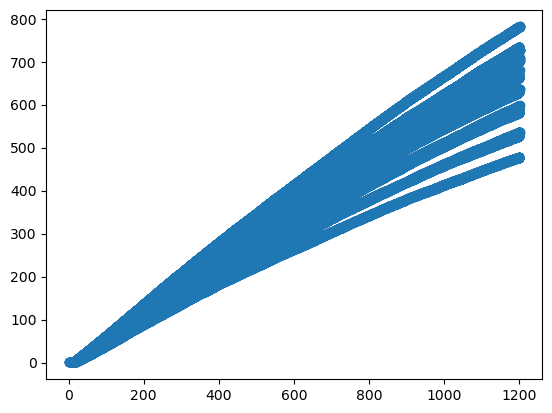

In [87]:
plt.scatter(combined_df["arrival_time"], combined_df["cumulative_inhibit"])

In [28]:
master_df = pd.merge(
    summary_df,
    IFCB_sampled_df,
    on="arrival_time",
    how="left"
)

print(master_df.head(15))

            scenario_id Source_group  arrival_time  total_particles  \
0   Alex25000_Jata25000         Jata      3.205586            50000   
1   Alex25000_Jata25000         Jata      3.205586            50000   
2   Alex25000_Jata25000         Jata      3.205586            50000   
3   Alex25000_Jata25000         Jata      3.370233            50000   
4   Alex25000_Jata25000         Jata      3.370233            50000   
5   Alex25000_Jata25000         Jata      5.690864            50000   
6   Alex25000_Jata25000  Alexandrium      7.157386            50000   
7   Alex25000_Jata25000  Alexandrium      7.157386            50000   
8   Alex25000_Jata25000  Alexandrium      7.157386            50000   
9   Alex25000_Jata25000  Alexandrium      7.157386            50000   
10  Alex25000_Jata25000  Alexandrium      7.157386            50000   
11  Alex25000_Jata25000  Alexandrium      7.243973            50000   
12  Alex25000_Jata25000  Alexandrium      7.243973            50000   
13  Al

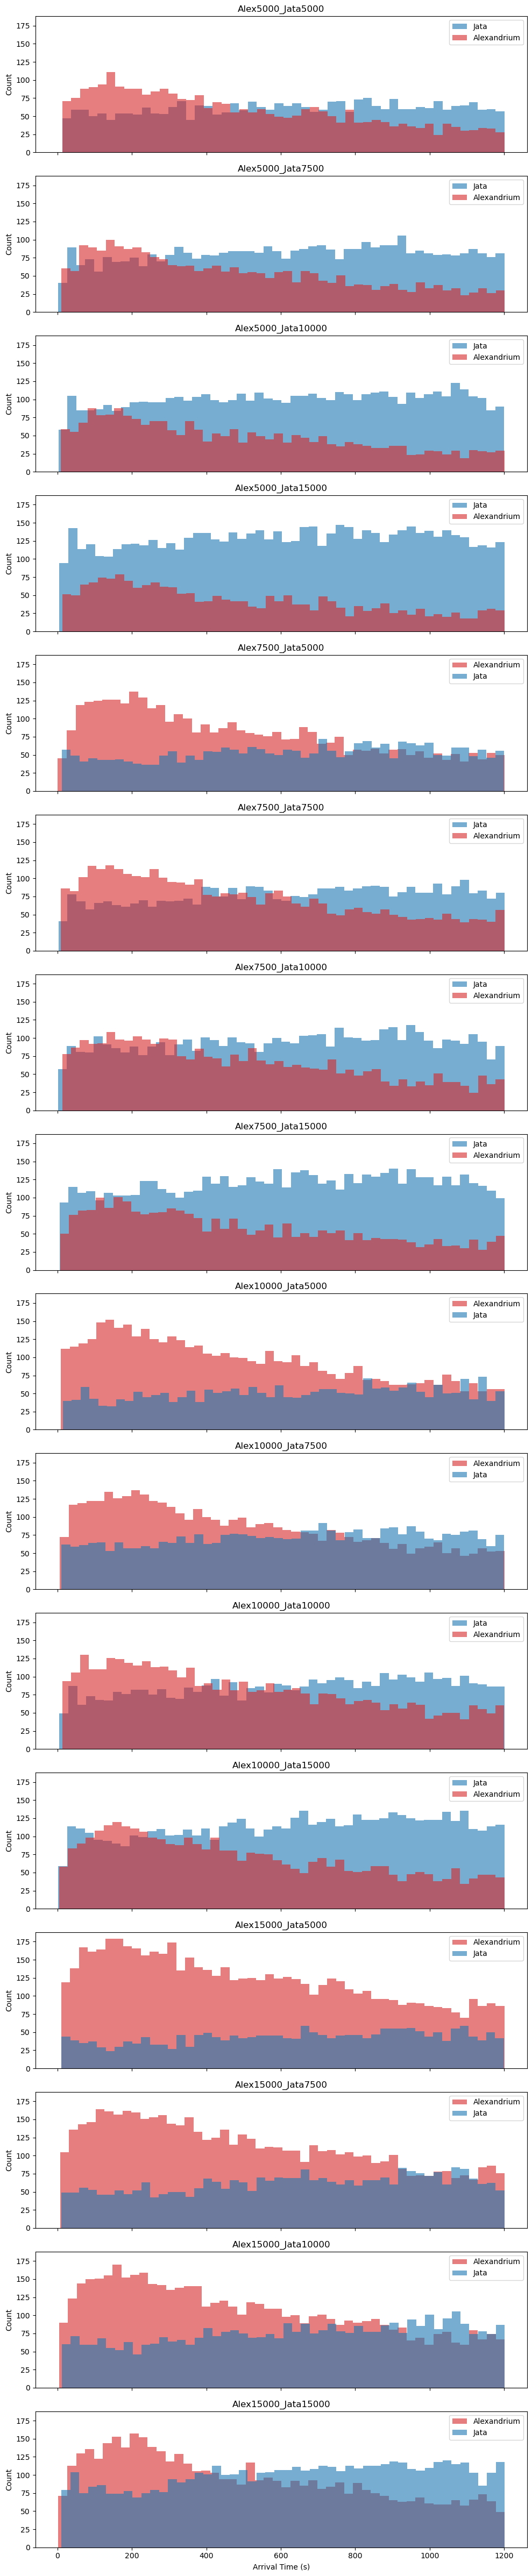

In [89]:
import matplotlib.pyplot as plt

scenarios = combined_df["scenario_id"].unique()

fig, axes = plt.subplots(
    len(scenarios), 1,
    figsize=(10, 3 * len(scenarios)),
    sharex=True,
    sharey=True
)

# If only one scenario, make axes iterable
if len(scenarios) == 1:
    axes = [axes]

colors = {
    "Alexandrium": "tab:red",
    "Jata": "tab:blue"
}

for ax, scenario in zip(axes, scenarios):

    df = combined_df[combined_df["scenario_id"] == scenario]
    df = df[df["sampled"] == True]

    for group in df["Source_group"].unique():
        ax.hist(
            df.loc[df["Source_group"] == group, "arrival_time"],
            bins=50,
            alpha=0.6,
            color=colors[group],
            label=group,
        )

    ax.set_title(scenario)
    ax.set_ylabel("Count")
    ax.legend()

axes[-1].set_xlabel("Arrival Time (s)")

plt.tight_layout()
plt.show()

In [108]:
concs_Alex_IFCB = []
concs_Jata_IFCB = []

scenarios = combined_df["scenario_id"].unique()


for scenario in scenarios:
    scenario_df = combined_df[combined_df["scenario_id"] == scenario]
    df = scenario_df[scenario_df["sampled"] == True]

    volume_analyzed = (df["arrival_time"].max() - df["cumulative_inhibit"].max())/240

    conc_Alex = len(df[df["Source_group"] == "Alexandrium"]) / volume_analyzed
    conc_Jata = len(df[df["Source_group"] == "Jata"]) / volume_analyzed

    concs_Alex_IFCB.append(conc_Alex)
    concs_Jata_IFCB.append(conc_Jata)



concs_IFCB_df = pd.DataFrame({
    "scenario_id": scenarios,
    "IFCB_concentration_Alex": concs_Alex_IFCB,
    "IFCB_concentration_Jata": concs_Jata_IFCB
})

print(concs_IFCB_df)

            scenario_id  IFCB_concentration_Alex  IFCB_concentration_Jata
0     Alex5000_Jata5000               969.537547              1010.004047
1    Alex5000_Jata10000               942.418894              1966.718794
2    Alex5000_Jata15000               979.698269              2952.945395
3    Alex5000_Jata20000               960.322867              3848.046986
4    Alex5000_Jata25000               938.279892              4769.058202
5    Alex5000_Jata30000               903.166256              5673.311820
6    Alex5000_Jata35000               995.582320              6693.672127
7    Alex10000_Jata5000              1837.519813               981.948879
8   Alex10000_Jata10000              1852.768453              1931.398139
9   Alex10000_Jata15000              1820.091655              2896.932100
10  Alex10000_Jata20000              1852.433175              3904.215673
11  Alex10000_Jata25000              1839.878385              4737.128819
12  Alex10000_Jata30000              1

In [109]:
concs_master_df = pd.merge(
    concs_df,
    concs_IFCB_df,
    on="scenario_id",
    how="left"
)

print(concs_master_df)

            scenario_id  concentration_Alex  concentration_Jata  \
0     Alex5000_Jata5000              1006.8              1021.4   
1    Alex5000_Jata10000              1019.6              2029.8   
2    Alex5000_Jata15000              1011.6              3004.2   
3    Alex5000_Jata20000              1013.8              3958.6   
4    Alex5000_Jata25000               997.6              4954.0   
5    Alex5000_Jata30000               987.2              5953.6   
6    Alex5000_Jata35000              1030.0              6996.6   
7    Alex10000_Jata5000              2027.6              1021.0   
8   Alex10000_Jata10000              2016.4              2003.4   
9   Alex10000_Jata15000              2019.4              2964.2   
10  Alex10000_Jata20000              1996.6              3958.8   
11  Alex10000_Jata25000              1981.8              4957.6   
12  Alex10000_Jata30000              2042.4              5996.8   
13  Alex10000_Jata35000              1997.0              6997.

In [110]:
concs_master_df["Alex_bias"] = (
    concs_master_df["IFCB_concentration_Alex"] -
    concs_master_df["concentration_Alex"]
) / concs_master_df["concentration_Alex"] * 100

concs_master_df["Jata_bias"] = (
    concs_master_df["IFCB_concentration_Jata"] -
    concs_master_df["concentration_Jata"]
) / concs_master_df["concentration_Jata"] * 100

print(concs_master_df)

            scenario_id  concentration_Alex  concentration_Jata  \
0     Alex5000_Jata5000              1006.8              1021.4   
1    Alex5000_Jata10000              1019.6              2029.8   
2    Alex5000_Jata15000              1011.6              3004.2   
3    Alex5000_Jata20000              1013.8              3958.6   
4    Alex5000_Jata25000               997.6              4954.0   
5    Alex5000_Jata30000               987.2              5953.6   
6    Alex5000_Jata35000              1030.0              6996.6   
7    Alex10000_Jata5000              2027.6              1021.0   
8   Alex10000_Jata10000              2016.4              2003.4   
9   Alex10000_Jata15000              2019.4              2964.2   
10  Alex10000_Jata20000              1996.6              3958.8   
11  Alex10000_Jata25000              1981.8              4957.6   
12  Alex10000_Jata30000              2042.4              5996.8   
13  Alex10000_Jata35000              1997.0              6997.

ValueError: x and y must have same first dimension, but have shapes (4,) and (16,)

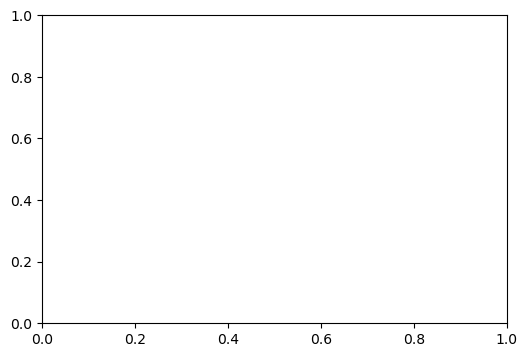

In [74]:
import matplotlib.pyplot as plt

fraction_alex = [20, 40, 60, 80]

plt.figure(figsize=(6,4))

plt.plot(
    fraction_alex,
    concs_master_df["Alex_bias"],
    "o-r",
    label="Alexandrium"
)

plt.plot(
    fraction_alex,
    concs_master_df["Jata_bias"],
    "s-b",
    label="Jata"
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Alexandrium fraction (%)")
plt.ylabel("Bias (%)")
plt.legend()
plt.tight_layout()
plt.show()

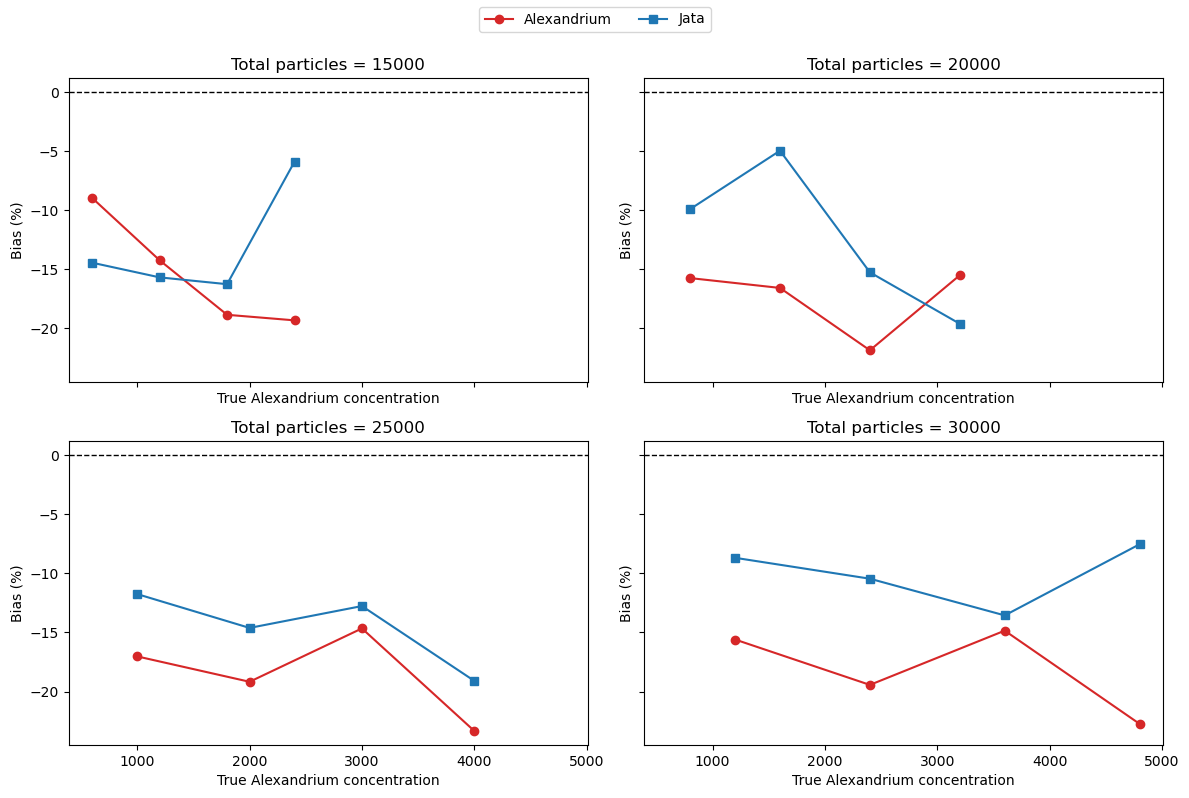

In [75]:
import numpy as np
import matplotlib.pyplot as plt

df = concs_master_df.copy()

# Extract total particle load from strings like "20A:80J_15000"
df["total_particles"] = df["scenario_id"].str.rsplit("_", n=1).str[-1].astype(int)

totals = sorted(df["total_particles"].unique())

ncols = 2
nrows = int(np.ceil(len(totals) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, total in zip(axes, totals):
    sub = df[df["total_particles"] == total].sort_values("concentration_Alex")

    ax.plot(
        sub["concentration_Alex"],
        sub["Alex_bias"],
        marker="o",
        linestyle="-",
        color="tab:red",
        label="Alexandrium"
    )

    ax.plot(
        sub["concentration_Alex"],
        sub["Jata_bias"],
        marker="s",
        linestyle="-",
        color="tab:blue",
        label="Jata"
    )

    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.set_title(f"Total particles = {total}")
    ax.set_xlabel("True Alexandrium concentration")
    ax.set_ylabel("Bias (%)")

# Remove any empty panels
for ax in axes[len(totals):]:
    fig.delaxes(ax)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

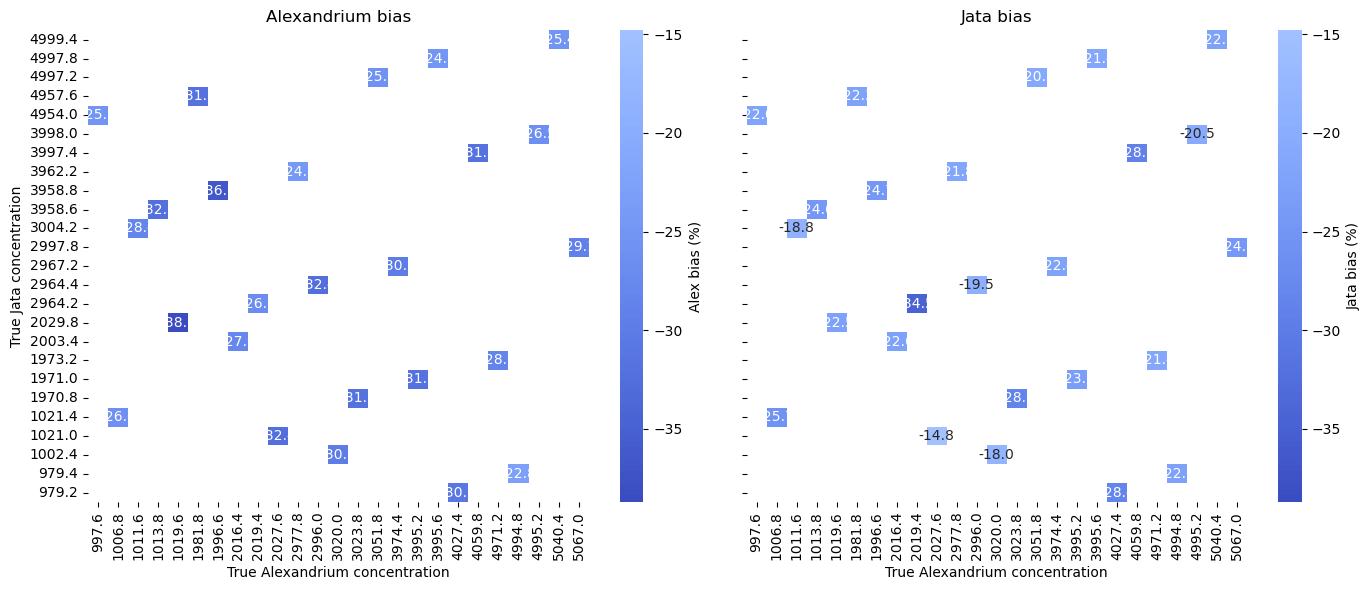

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

df = concs_master_df.copy()

# If needed, make sure concentrations are numeric
df["concentration_Alex"] = pd.to_numeric(df["concentration_Alex"])
df["concentration_Jata"] = pd.to_numeric(df["concentration_Jata"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)


## Min and max bias for plotting
vmin = min(df["Alex_bias"].min(), df["Jata_bias"].min())
vmax = max(df["Alex_bias"].max(), df["Jata_bias"].max())

# Alexandrium bias heatmap
alex_grid = df.pivot_table(
    index="concentration_Jata",
    columns="concentration_Alex",
    values="Alex_bias",
    aggfunc="mean"
)
alex_grid = alex_grid.sort_index(ascending=False)


sns.heatmap(
    alex_grid,
    ax=axes[0],
    cmap="coolwarm",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Alex bias (%)"}
)
axes[0].set_title("Alexandrium bias")
axes[0].set_xlabel("True Alexandrium concentration")
axes[0].set_ylabel("True Jata concentration")

# Jata bias heatmap
jata_grid = df.pivot_table(
    index="concentration_Jata",
    columns="concentration_Alex",
    values="Jata_bias",
    aggfunc="mean"
)

jata_grid = jata_grid.sort_index(ascending=False)

sns.heatmap(
    jata_grid,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Jata bias (%)"}
)
axes[1].set_title("Jata bias")
axes[1].set_xlabel("True Alexandrium concentration")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [111]:
alex_vals_grid = [x / 5 for x in alex_vals]
jata_vals_grid = [x / 5 for x in jata_vals]

print("Alex grid values:", alex_vals_grid)
print("Jata grid values:", jata_vals_grid)


Alex grid values: [1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0]
Jata grid values: [1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0]


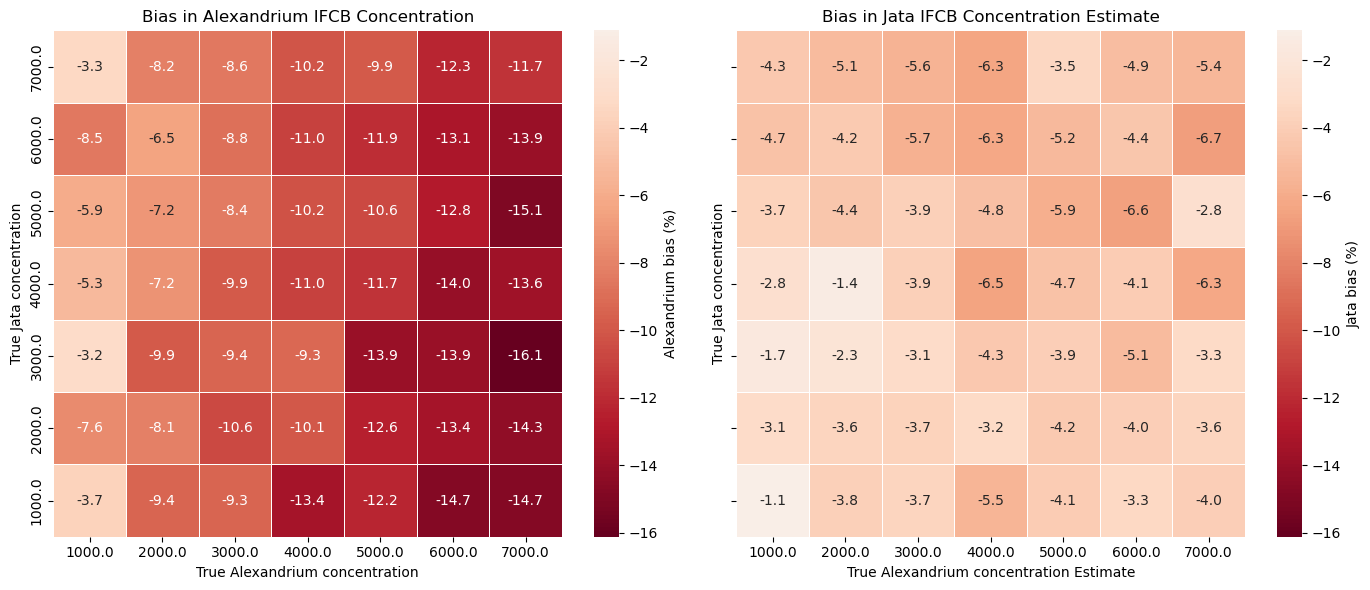

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = concs_master_df.copy()

# make sure these are numeric
df["concentration_Alex"] = pd.to_numeric(df["concentration_Alex"])
df["concentration_Jata"] = pd.to_numeric(df["concentration_Jata"])

# your intended grid values
alex_levels = np.array(alex_vals_grid, dtype=float)
jata_levels = np.array(jata_vals_grid, dtype=float)

# snap jittered values to nearest intended grid point
def snap_to_grid(x, levels):
    return levels[np.argmin(np.abs(levels - x))]

df["alex_grid"] = df["concentration_Alex"].apply(lambda x: snap_to_grid(x, alex_levels))
df["jata_grid"] = df["concentration_Jata"].apply(lambda x: snap_to_grid(x, jata_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(df["Alex_bias"].min(), df["Jata_bias"].min())
vmax = max(df["Alex_bias"].max(), df["Jata_bias"].max())

# Alexandrium bias
alex_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="Alex_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    alex_grid,
    ax=axes[0],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Alexandrium bias (%)"}
)
axes[0].set_title("Bias in Alexandrium IFCB Concentration")
axes[0].set_xlabel("True Alexandrium concentration")
axes[0].set_ylabel("True Jata concentration")

# Jata bias
jata_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="Jata_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    jata_grid,
    ax=axes[1],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Jata bias (%)"}
)
axes[1].set_title("Bias in Jata IFCB Concentration Estimate")
axes[1].set_xlabel("True Alexandrium concentration Estimate")
axes[1].set_ylabel("True Jata concentration")

plt.tight_layout()
plt.show()

In [ ]:
test_df = combined_df[combined_df["scenario_id"] == "Alex20000_Jata20000"].copy()

In [123]:
scenarios = summary_df["scenario_id"].unique()
max_inhibits = []

for scenario in scenarios:
    scenario_df = combined_df[combined_df["scenario_id"] == scenario]
    max_inhibit = scenario_df["cumulative_inhibit"].max()
    max_inhibits.append(max_inhibit)

    Frames = scenario__df[scenario_df[]]

inhibit_summary_df = pd.DataFrame({
    "scenario_id": scenarios,
    "max_cumulative_inhibit": max_inhibits
})

print(inhibit_summary_df)

            scenario_id  max_cumulative_inhibit
0     Alex5000_Jata5000                  477.44
1    Alex5000_Jata10000                  591.20
2    Alex5000_Jata15000                  681.44
3    Alex5000_Jata20000                  740.24
4    Alex5000_Jata25000                  787.84
5    Alex5000_Jata30000                  825.44
6    Alex5000_Jata35000                  864.40
7    Alex10000_Jata5000                  581.84
8   Alex10000_Jata10000                  669.92
9   Alex10000_Jata15000                  734.16
10  Alex10000_Jata20000                  790.08
11  Alex10000_Jata25000                  825.04
12  Alex10000_Jata30000                  863.28
13  Alex10000_Jata35000                  887.68
14   Alex15000_Jata5000                  663.36
15  Alex15000_Jata10000                  727.44
16  Alex15000_Jata15000                  781.92
17  Alex15000_Jata20000                  821.84
18  Alex15000_Jata25000                  861.20
19  Alex15000_Jata30000                 

In [124]:

reps = range(1, 2)
Jata_results_df = pd.DataFrame()
Alex_results_df = pd.DataFrame()
alex_vals = [ 5000, 10000, 15000, 20000, 25000, 30000, 35000]
jata_vals = [ 5000, 10000, 15000, 20000, 25000, 30000, 35000]

for rep in reps: 
    summary_df = pd.DataFrame()

    for alex in alex_vals:
        for jata in jata_vals:
            df = make_mixture_from_concentrations(
                Arrivals_A=Alex_corrected["arrival_times"],
                Type_A="Alexandrium",
                Arrivals_B=Jata_corrected["arrival_times"],
                Type_B="Jata",
                alex_conc=alex,
                jata_conc=jata,
                scenario_id=f"Alex{alex}_Jata{jata}",
                seed=42+alex+jata+rep,
            )

            summary_df = pd.concat([summary_df, df], ignore_index=True)

    concs_Alex = []
    concs_Jata = []

    scenarios = summary_df["scenario_id"].unique()


    for scenario in scenarios:
        df = summary_df[summary_df["scenario_id"] == scenario]

        conc_Alex = len(df[df["Source_group"] == "Alexandrium"]) / 5
        conc_Jata = len(df[df["Source_group"] == "Jata"]) / 5

        concs_Alex.append(conc_Alex)
        concs_Jata.append(conc_Jata)



    concs_df = pd.DataFrame({
        "scenario_id": scenarios,
        "concentration_Alex": concs_Alex,
        "concentration_Jata": concs_Jata
    })

    combined_df = pd.DataFrame()

    for scenario in summary_df["scenario_id"].unique():
        scenario_df = summary_df[summary_df["scenario_id"] == scenario]
        sampled_df = simulate_ifcb_sampling_df(scenario_df, "arrival_time", inhibit_time=0.08)
        combined_df = pd.concat([combined_df, sampled_df], ignore_index=True)

    concs_Alex_IFCB = []
    concs_Jata_IFCB = []

    scenarios = combined_df["scenario_id"].unique()


    for scenario in scenarios:
        scenario_df = combined_df[combined_df["scenario_id"] == scenario]
        df = scenario_df[scenario_df["sampled"] == True]

        volume_analyzed = (df["arrival_time"].max() - df["cumulative_inhibit"].max())/240

        conc_Alex = len(df[df["Source_group"] == "Alexandrium"]) / volume_analyzed
        conc_Jata = len(df[df["Source_group"] == "Jata"]) / volume_analyzed

        concs_Alex_IFCB.append(conc_Alex)
        concs_Jata_IFCB.append(conc_Jata)



    concs_IFCB_df = pd.DataFrame({
        "scenario_id": scenarios,
        "IFCB_concentration_Alex": concs_Alex_IFCB,
        "IFCB_concentration_Jata": concs_Jata_IFCB
    })

    concs_master_df = pd.merge(
    concs_df,
    concs_IFCB_df,
    on="scenario_id",
    how="left"
    )

    concs_master_df["Alex_bias"] = (
    concs_master_df["IFCB_concentration_Alex"] -
    concs_master_df["concentration_Alex"]
    ) / concs_master_df["concentration_Alex"] * 100

    concs_master_df["Jata_bias"] = (
    concs_master_df["IFCB_concentration_Jata"] -
    concs_master_df["concentration_Jata"]
    ) / concs_master_df["concentration_Jata"] * 100

    Jata_results_df = pd.concat([Jata_results_df, concs_master_df[["scenario_id", "Jata_bias"]].assign(rep=rep)], ignore_index=True)
    Alex_results_df = pd.concat([Alex_results_df, concs_master_df[["scenario_id", "Alex_bias"]].assign(rep=rep)], ignore_index=True)

        

In [125]:
print(Jata_results_df.head())

          scenario_id  Jata_bias  rep
0   Alex5000_Jata5000  -2.324177    1
1  Alex5000_Jata10000  -0.199556    1
2  Alex5000_Jata15000  -2.335470    1
3  Alex5000_Jata20000  -2.993444    1
4  Alex5000_Jata25000  -4.385324    1


In [133]:
import numpy as np
import pandas as pd

reps = range(1, 11)

alex_vals = [5000, 10000, 15000, 20000, 25000, 30000, 35000]
jata_vals = [5000, 10000, 15000, 20000, 25000, 30000, 35000]

results = []

for rep in reps:
    for alex in alex_vals:
        for jata in jata_vals:
            scenario_id = f"Alex{alex}_Jata{jata}"

            mix_df = make_mixture_from_concentrations(
                Arrivals_A=Alex_corrected["arrival_times"],
                Type_A="Alexandrium",
                Arrivals_B=Jata_corrected["arrival_times"],
                Type_B="Jata",
                alex_conc=alex,
                jata_conc=jata,
                scenario_id=scenario_id,
                seed=42 + rep * 1_000_000 + alex * 100 + jata,
            )

            sampled_df = simulate_ifcb_sampling_df(
                mix_df,
                "arrival_time",
                inhibit_time=0.08
            )

            true_alex = (mix_df["Source_group"] == "Alexandrium").sum() / 5
            true_jata = (mix_df["Source_group"] == "Jata").sum() / 5

            sampled_only = sampled_df.loc[sampled_df["sampled"]].copy()

            if sampled_only.empty:
                ifcb_alex = np.nan
                ifcb_jata = np.nan
                vol = np.nan
            else:
                vol = (
                    sampled_only["arrival_time"].max()
                    - sampled_only["cumulative_inhibit"].max()
                ) / 240

                if vol <= 0 or pd.isna(vol):
                    ifcb_alex = np.nan
                    ifcb_jata = np.nan
                else:
                    ifcb_alex = (sampled_only["Source_group"] == "Alexandrium").sum() / vol
                    ifcb_jata = (sampled_only["Source_group"] == "Jata").sum() / vol

            alex_bias = np.nan if true_alex == 0 or pd.isna(ifcb_alex) else (ifcb_alex - true_alex) / true_alex * 100
            jata_bias = np.nan if true_jata == 0 or pd.isna(ifcb_jata) else (ifcb_jata - true_jata) / true_jata * 100

            results.append({
                "rep": rep,
                "scenario_id": scenario_id,
                "alex_concentration": alex,
                "jata_concentration": jata,
                "true_alex_conc": true_alex,
                "true_jata_conc": true_jata,
                "ifcb_alex_conc": ifcb_alex,
                "ifcb_jata_conc": ifcb_jata,
                "Alex_bias": alex_bias,
                "Jata_bias": jata_bias,
            })

results_df = pd.DataFrame(results)

In [136]:
print(results_df.head())


   rep         scenario_id  alex_concentration  jata_concentration  \
0    1   Alex5000_Jata5000                5000                5000   
1    1  Alex5000_Jata10000                5000               10000   
2    1  Alex5000_Jata15000                5000               15000   
3    1  Alex5000_Jata20000                5000               20000   
4    1  Alex5000_Jata25000                5000               25000   

   true_alex_conc  true_jata_conc  ifcb_alex_conc  ifcb_jata_conc  Alex_bias  \
0           982.6          1025.0      941.382810     1020.382281  -4.194707   
1           999.0          1995.2      957.594867     1946.257493  -4.144658   
2           993.4          2995.8      929.957394     2907.369247  -6.386411   
3          1002.0          3992.4      922.781572     3895.147933  -7.906031   
4           987.6          4973.4      913.498443     4850.005474  -7.503195   

   Jata_bias  
0  -0.450509  
1  -2.453013  
2  -2.951824  
3  -2.435930  
4  -2.481090  


In [144]:
scenarios = results_df["scenario_id"].unique()
jata_biases = []
alex_biases = []
jata_concentrations = []
alex_concentrations = []
for scenario in scenarios:
    average_jata_bias = results_df[results_df["scenario_id"] == scenario]["Jata_bias"].mean()
    average_alex_bias = results_df[results_df["scenario_id"] == scenario]["Alex_bias"].mean()
    average_jata = results_df[results_df["scenario_id"] == scenario]["true_jata_conc"].mean()
    average_alex = results_df[results_df["scenario_id"] == scenario]["true_alex_conc"].mean()
    jata_biases.append(average_jata_bias)
    alex_biases.append(average_alex_bias)
    jata_concentrations.append(average_jata)
    alex_concentrations.append(average_alex)

plotting_df = pd.DataFrame({
    "scenario_id": scenarios,
    "average_Jata_bias": jata_biases,
    "average_Alex_bias": alex_biases,
    "concentration_Alex": alex_concentrations,
    "concentration_Jata": jata_concentrations
})

print(plotting_df.head())

          scenario_id  average_Jata_bias  average_Alex_bias  \
0   Alex5000_Jata5000          -1.916007          -5.163805   
1  Alex5000_Jata10000          -2.548134          -4.794976   
2  Alex5000_Jata15000          -2.709909          -4.795082   
3  Alex5000_Jata20000          -3.245233          -5.213791   
4  Alex5000_Jata25000          -3.266314          -6.256090   

   concentration_Alex  concentration_Jata  
0              998.92             1006.50  
1              998.28             1997.66  
2             1001.54             2998.40  
3              998.20             3981.82  
4             1005.36             5001.60  


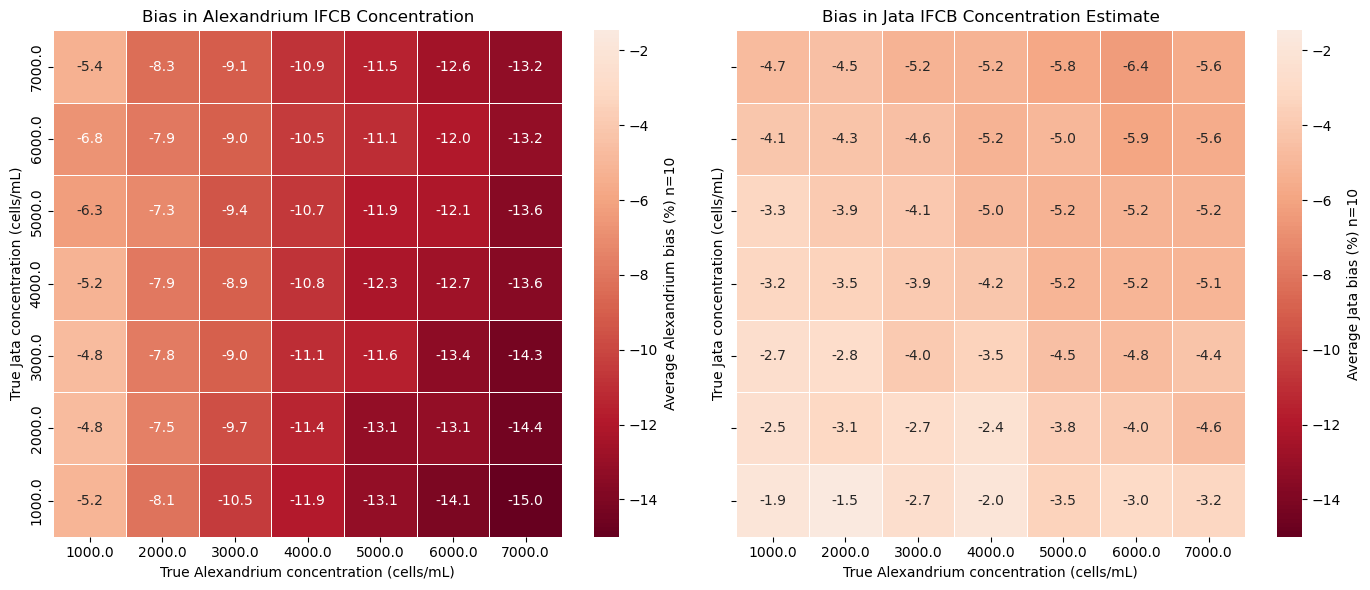

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = plotting_df.copy()

# make sure these are numeric
df["concentration_Alex"] = pd.to_numeric(df["concentration_Alex"])
df["concentration_Jata"] = pd.to_numeric(df["concentration_Jata"])

# your intended grid values
alex_levels = np.array(alex_vals_grid, dtype=float)
jata_levels = np.array(jata_vals_grid, dtype=float)

# snap jittered values to nearest intended grid point
def snap_to_grid(x, levels):
    return levels[np.argmin(np.abs(levels - x))]

df["alex_grid"] = df["concentration_Alex"].apply(lambda x: snap_to_grid(x, alex_levels))
df["jata_grid"] = df["concentration_Jata"].apply(lambda x: snap_to_grid(x, jata_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(df["average_Alex_bias"].min(), df["average_Jata_bias"].min())
vmax = max(df["average_Alex_bias"].max(), df["average_Jata_bias"].max())

# Alexandrium bias
alex_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="average_Alex_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    alex_grid,
    ax=axes[0],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average Alexandrium bias (%) n=10"}
)
axes[0].set_title("Bias in Alexandrium IFCB Concentration")
axes[0].set_xlabel("True Alexandrium concentration (cells/mL)")
axes[0].set_ylabel("True Jata concentration (cells/mL)")

# Jata bias
jata_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="average_Jata_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    jata_grid,
    ax=axes[1],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average Jata bias (%) n=10"}
)
axes[1].set_title("Bias in Jata IFCB Concentration Estimate")
axes[1].set_xlabel("True Alexandrium concentration (cells/mL)")
axes[1].set_ylabel("True Jata concentration (cells/mL)")

plt.tight_layout()
plt.show()